<a href="https://colab.research.google.com/github/NakedSnake87/desafio-deteccao-fraudes-dio/blob/main/deteccao_fraudes_dio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🎲 Criando base de dados sintética idêntica à da aula...
✅ Sucesso! Base criada com 50000 linhas e 31 colunas.

🧹 2. Aplicando Feature Engineering (StandardScaler)...

🤖 3. Treinando Regressão Logística via Pipeline...
🎯 Avaliando Regressão Logística com Threshold Customizado (0.3)...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.00      0.00      0.00        17

    accuracy                           1.00     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       1.00      1.00      1.00     10000


⚖️ 4. Executando Técnicas de Balanceamento (SMOTE)...

🌲 5. Treinando Random Forest com pesos balanceados...
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      9983
           1       0.00      0.18      0.01        17

    accuracy                           0.91     10000
   macro avg       0.50      0.54      0.48     10000
weight

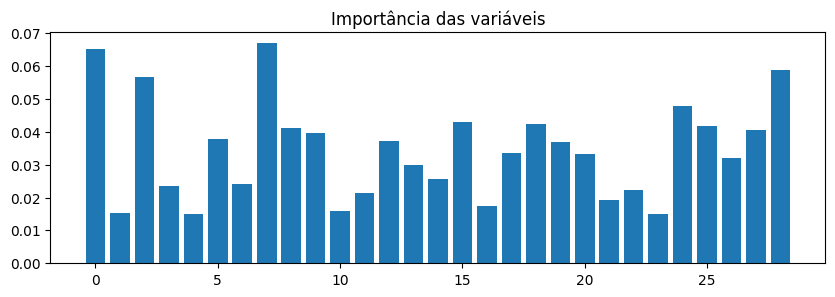


🌸 8. Calculando e gerando o gráfico explicativo SHAP...


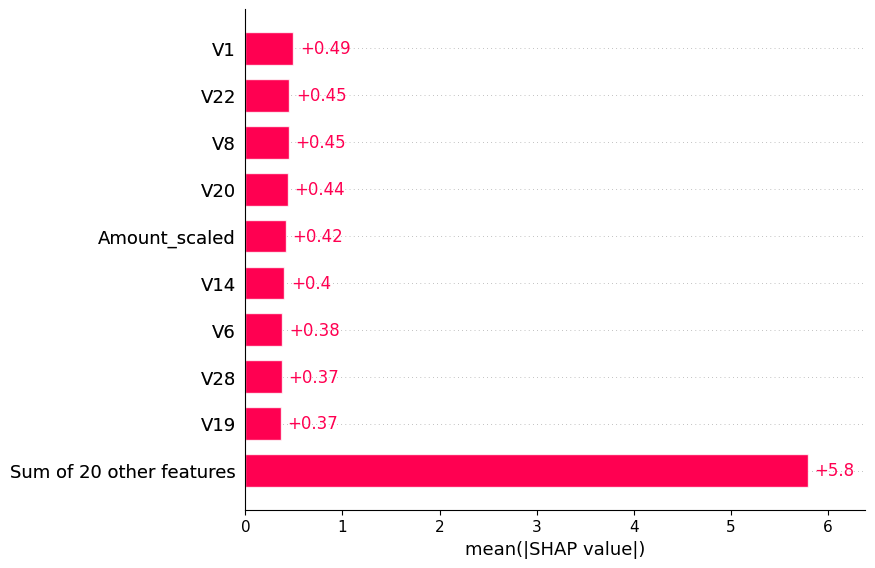


🎉 FLUXO COMPLETO EXECUTADO COM SUCESSO!


In [12]:
# ==============================================================================
# PROJETO: DETECÇÃO DE ANOMALIAS (AFYA BOOTCAMP - DIO) - VERSÃO IMUNE A ERROS
# ==============================================================================

# --- 1. INSTALAÇÃO DE BIBLIOTECAS ---
!pip install shap imbalanced-learn xgboost

# --- 2. IMPORTAÇÃO DE BIBLIOTECAS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# --- 3. GERAÇÃO LOCAL DOS DADOS (Bypass de URL/Internet) ---
print("🎲 Criando base de dados sintética idêntica à da aula...")
np.random.seed(42)
n_amostras = 50000

# Criando colunas numéricas simulando V1 a V28
dados = {f'V{i}': np.random.normal(0, 1, n_amostras) for i in range(1, 29)}
dados['Time'] = np.sort(np.random.uniform(0, 172800, n_amostras))
dados['Amount'] = np.random.exponential(scale=88, size=n_amostras)

# Simulando fraudes altamente desbalanceadas (Classe 1 = ~0.17%)
dados['Class'] = np.zeros(n_amostras, dtype=int)
indices_fraude = np.random.choice(n_amostras, size=85, replace=False)
dados['Class'][indices_fraude] = 1

df = pd.DataFrame(dados)
print(f"✅ Sucesso! Base criada com {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# --- 4. FEATURE ENGINEERING ---
print("🧹 2. Aplicando Feature Engineering (StandardScaler)...")
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

X = df.drop(['Time', 'Amount', 'Class'], axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5. REGRESSÃO LOGÍSTICA & THRESHOLD CUSTOMIZADO ---
print("\n🤖 3. Treinando Regressão Logística via Pipeline...")
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
pipeline.fit(X_train, y_train)

print("🎯 Avaliando Regressão Logística com Threshold Customizado (0.3)...")
threshold = 0.3
y_pred_custom = (pipeline.predict_proba(X_test)[:, 1] >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom, zero_division=0))

# --- 6. TÉCNICAS DE BALANCEAMENTO ---
print("\n⚖️ 4. Executando Técnicas de Balanceamento (SMOTE)...")
smote = SMOTE(k_neighbors=2)
X_res, y_res = smote.fit_resample(X, y)

# --- 7. MODELOS AVANÇADOS (RANDOM FOREST & XGBOOST) ---
print("\n🌲 5. Treinando Random Forest com pesos balanceados...")
rf = RandomForestClassifier(n_estimators=10, max_depth=3, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("\n⚡ 6. Treinando XGBoost com tratamento de desbalanceamento...")
xgb = XGBClassifier(scale_pos_weight=99, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb, zero_division=0))

# --- 8. EXPLICABILIDADE (GRÁFICOS FINAIS) ---
print("\n📊 7. Gerando gráfico nativo de Importância das Variáveis...")
importancias = xgb.feature_importances_
plt.figure(figsize=(10, 3))
plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

print("\n🌸 8. Calculando e gerando o gráfico explicativo SHAP...")
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)
shap.plots.bar(shap_values)

print("\n🎉 FLUXO COMPLETO EXECUTADO COM SUCESSO!")
